# Automated safety interlock verification, walkthrough

This notebook reads what the pipeline produced. It does not rerun the study, so
nothing in here can disagree with `results/`. If a number looks wrong, the fix
is in `src/`, not here.

Run `python src/run_study.py --cached-only --attempts 1` and `python src/make_figures.py` first.

In [1]:
import json, os, sys
sys.path.insert(0, os.path.abspath("../src"))
sys.path.insert(0, os.path.abspath("../tests"))
from IPython.display import Image, display

RESULTS = os.path.abspath("../results")
FIGS = os.path.join(RESULTS, "figures")

## 1. The machine

Every threshold in this project is a multiple of the rated current of a real
motor, and the two percentages are the ones I set in TIA Portal on the machines
I commissioned.

In [2]:
from tag_list import (MOTOR, RATED_CURRENT_A, SAFE_MODE_CURRENT_A,
                      SHUTDOWN_CURRENT_A, INSULATION_LIMIT_C, tag_list_for_prompt)

print(f"{MOTOR.rated_power_kw} kW, {MOTOR.voltage_v} V, insulation class {MOTOR.insulation_class}")
print(f"rated current          {RATED_CURRENT_A:6.1f} A")
print(f"safe mode at 110 pct   {SAFE_MODE_CURRENT_A:6.1f} A")
print(f"shutdown at 125 pct    {SHUTDOWN_CURRENT_A:6.1f} A")
print(f"locked rotor           {RATED_CURRENT_A * MOTOR.locked_rotor_multiple:6.1f} A")
print(f"insulation limit       {INSULATION_LIMIT_C:6.1f} degC")

22.0 kW, 400.0 V, insulation class F
rated current            41.5 A
safe mode at 110 pct     45.6 A
shutdown at 125 pct      51.9 A
locked rotor            249.0 A
insulation limit        155.0 degC


## 2. The faults

Seven fault families. Two of them are healthy, included so the study can count
interlocks that trip when nothing is wrong. An interlock that nuisance trips
gets bypassed by an operator, and a bypassed interlock protects nobody.

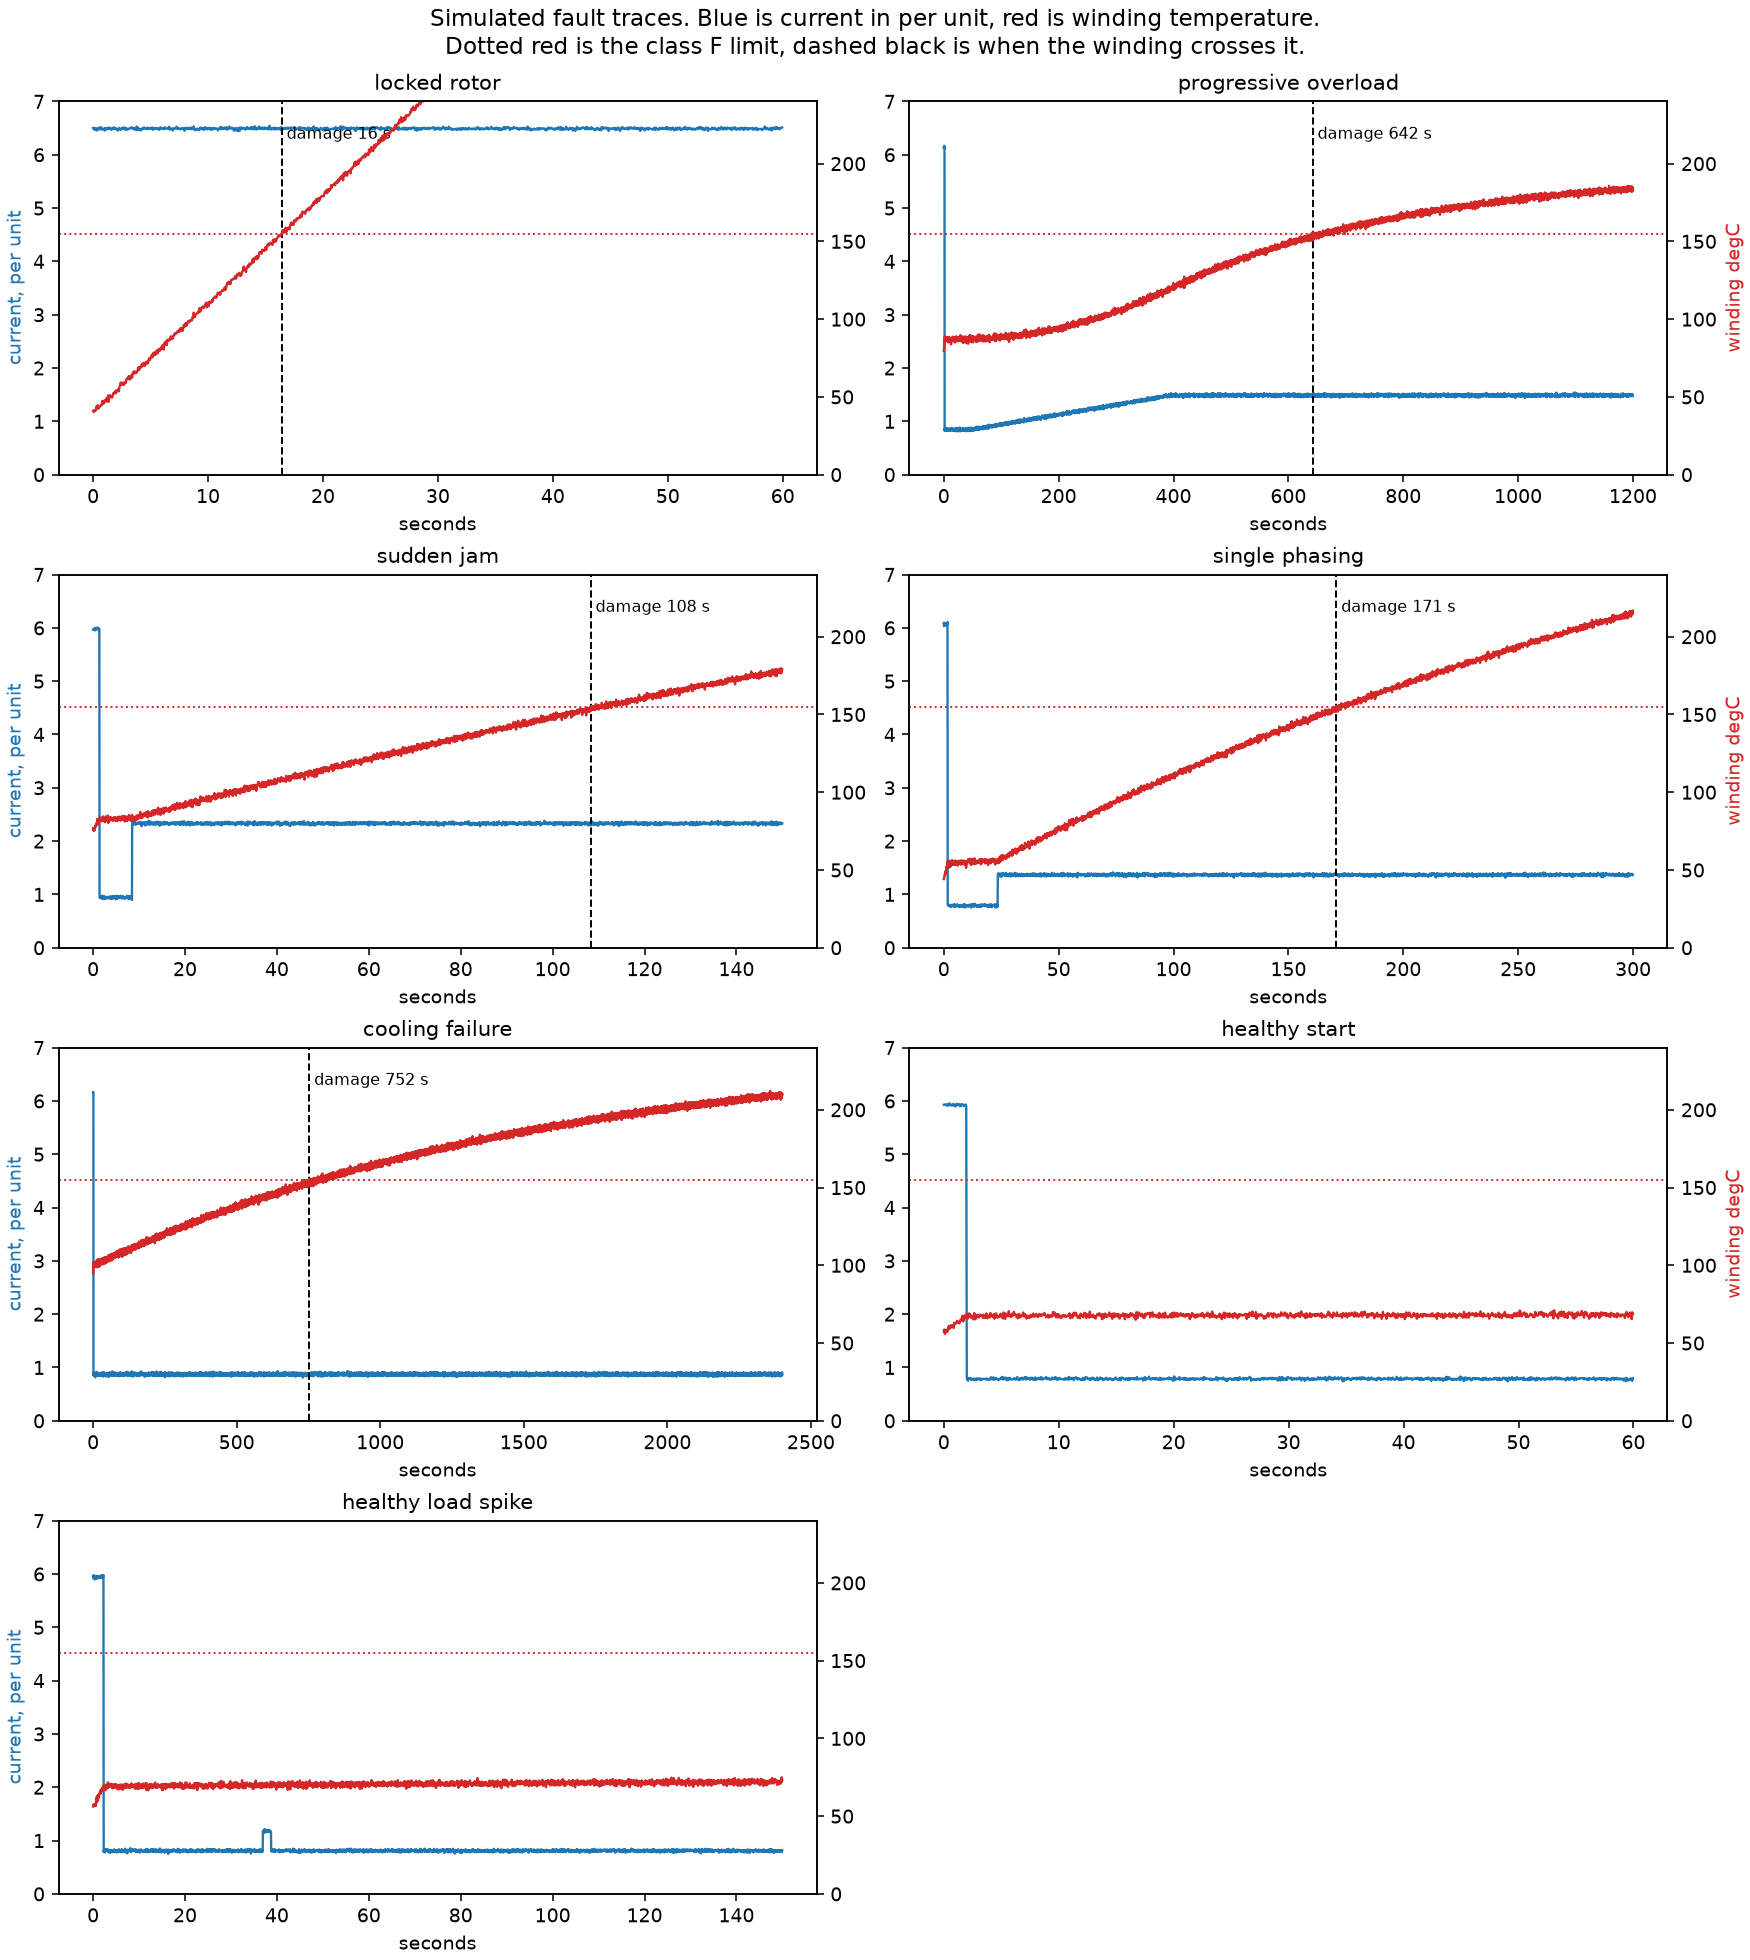

In [3]:
display(Image(os.path.join(FIGS, "fault_traces.png")))

## 3. The question the rule checker cannot answer

This is the whole argument for having a second layer. Below is the trip delay
swept across three orders of magnitude with the threshold pinned at the 125
percent setting. Short delays nuisance trip on starting current. Long delays let
a stalled rotor cook. Both ends are made of numbers that look perfectly
reasonable on their own, and no static rule that looks at one parameter at a
time can tell them apart.

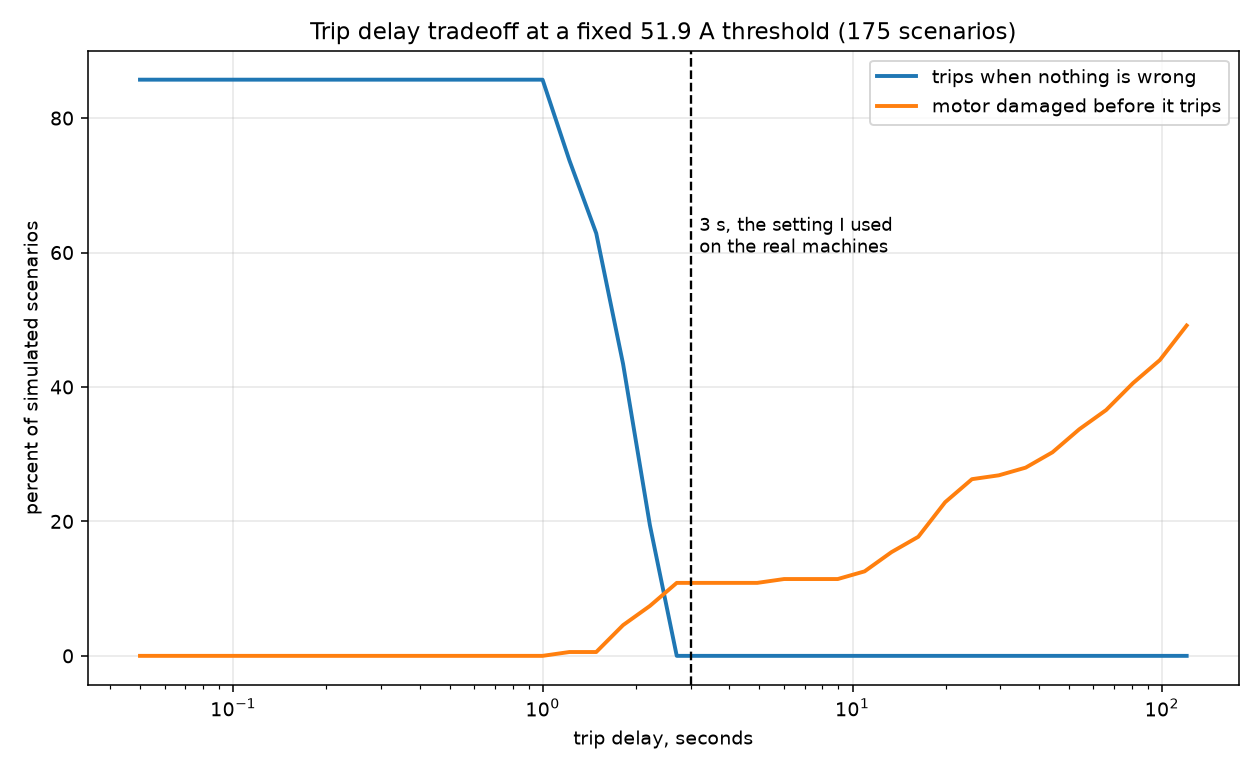

In [4]:
display(Image(os.path.join(FIGS, "delay_tradeoff.png")))

## 4. Stage 2, the deterministic checker

Every hand written case with a known fault. Most must be caught and two
must not be, and the two that must not be are the reason stage 3 exists.

In [5]:
from known_bad_cases import CASES
from rule_checker import check_code, extract_parameters

for case in CASES:
    found = sorted({f.rule_id for f in check_code(case.code, case.requirement)})
    expected = sorted(set(case.expected_rules))
    mark = "ok " if found == expected else "BAD"
    print(f"{mark} {case.name:46s} {found}")

ok  good_baseline                                  []
ok  hallucinated_tag                               ['UNKNOWN_TAG']
ok  inverted_current_comparison                    ['INVERTED_COMPARISON']
ok  alarm_only_no_shutdown                         ['NO_SHUTDOWN_ACTION']
ok  missing_timer                                  ['MISSING_TIMER']
ok  timer_with_zero_preset                         ['MISSING_TIMER']
ok  threshold_below_rated                          ['THRESHOLD_OUT_OF_BAND']
ok  threshold_impossibly_high                      ['THRESHOLD_OUT_OF_BAND']
ok  temperature_above_insulation_limit             ['THRESHOLD_OUT_OF_BAND']
ok  inverted_speed_comparison                      ['INVERTED_COMPARISON']
ok  unbalanced_if_block                            ['PARSE_ERROR']
ok  empty_output                                   ['PARSE_ERROR']
ok  multiple_faults_at_once                        ['MISSING_TIMER', 'NO_SHUTDOWN_ACTION', 'UNKNOWN_TAG']
ok  named_constant_threshold                  

### The two that get through

Both of these pass every deterministic rule. The first trips at 150 percent
after 30 seconds, and on a locked rotor the winding is past its insulation limit
in under eight. The second is textbook correct and completely blind to a blocked
fan cowl.

In [6]:
from fault_sim import simulate_fault_family, evaluate_interlock
import numpy as np

rng = np.random.default_rng(5)
for name in ["physically_unsafe_but_structurally_perfect",
             "current_interlock_blind_to_cooling_failure"]:
    case = next(c for c in CASES if c.name == name)
    params = extract_parameters(case.code)
    print(f"{name}\n  stage 2 findings: {[f.rule_id for f in check_code(case.code, case.requirement)]}")
    print(f"  extracted: {params}")
    for fault in ["locked_rotor", "cooling_failure"]:
        verdicts = [evaluate_interlock(s, params, 0.05)[1]
                    for s in simulate_fault_family(fault, 10, rng, 0)]
        bad = sum(1 for v in verdicts if v != "safe")
        print(f"  {fault:20s} fails {bad} of 10")
    print()

physically_unsafe_but_structurally_perfect
  stage 2 findings: []
  extracted: InterlockParams(signal='Motor_Current', threshold=62.3, direction='high', delay_s=30.0, has_shutdown=True)
  locked_rotor         fails 10 of 10


  cooling_failure      fails 7 of 10

current_interlock_blind_to_cooling_failure
  stage 2 findings: []
  extracted: InterlockParams(signal='Motor_Current', threshold=51.9, direction='high', delay_s=3.0, has_shutdown=True)
  locked_rotor         fails 0 of 10


  cooling_failure      fails 6 of 10



## 5. Stage 3, the learned layer

Trained on five fault families, tested on two it has never seen. The bar chart
on the right is the one to read. Accuracy next to the majority class baseline,
because a model that always answers unsafe scores whatever the base rate is.

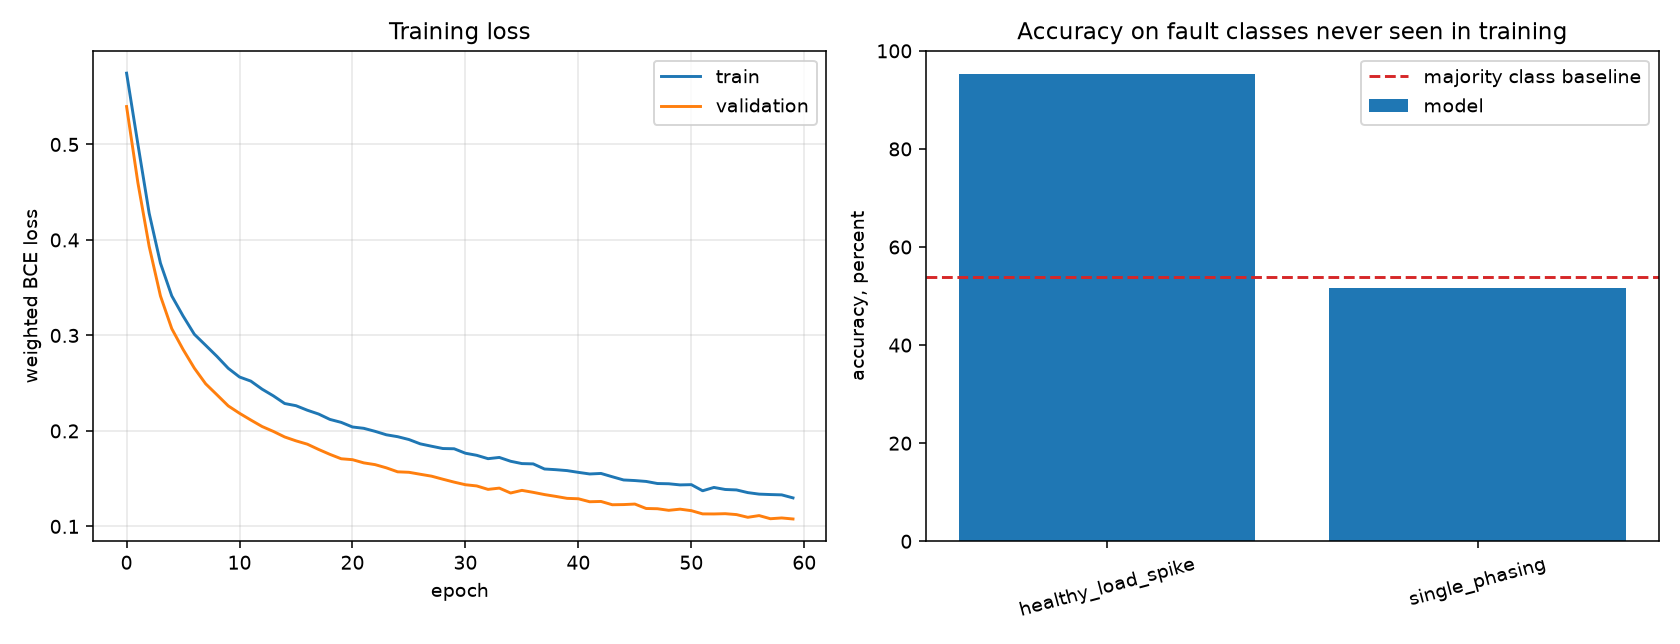

indist_accuracy                    0.953
heldout_accuracy                   0.735
heldout_majority_baseline          0.540
heldout_recall_unsafe              0.546
heldout_precision_unsafe           0.935
heldout_predicted_positive_rate    0.315
per class: {'healthy_load_spike': 0.952892561983471, 'single_phasing': 0.5163223140495867}


In [7]:
display(Image(os.path.join(FIGS, "training.png")))

with open(os.path.join(RESULTS, "training_history.json")) as fh:
    metrics = json.load(fh)["metrics"]
for key in ["indist_accuracy", "heldout_accuracy", "heldout_majority_baseline",
            "heldout_recall_unsafe", "heldout_precision_unsafe",
            "heldout_predicted_positive_rate"]:
    print(f"{key:34s} {metrics[key]:.3f}")
print(f"per class: {metrics['per_fault_accuracy']}")

## 6. The study

Two scopes. Scope A counts only failures the signal the interlock watches could
actually see. Scope B counts everything, including faults that signal is
physically blind to. The first version of this study reported only scope B, and
the headline unsafe rate was so high that both layers looked good for the wrong
reason.

Read every catch rate against the overall rejection rates printed first. A layer
that rejects almost everything catches almost everything, and that is not a
result.

In [8]:
name = "study_results.json"
if not os.path.exists(os.path.join(RESULTS, name)):
    name = "study_results_mock.json"
with open(os.path.join(RESULTS, name)) as fh:
    summary = json.load(fh)["summary"]

if summary.get("is_mock"):
    print("!! hand written stand in corpus, NOT LLM output !!\n")

def show(label, block):
    print(f"  {label:34s} {block['count']:4d} / {block['of']:<4d} "
          f"{block['rate']*100:6.1f} %   "
          f"[{block['ci_low']*100:5.1f}, {block['ci_high']*100:5.1f}]")

show("stage 2 rejected anything", summary["stage2_reject_rate_overall"])
show("stage 3 rejected anything", summary["stage3_reject_rate_overall"])
for scope in ["observable", "strict"]:
    print(f"\n  scope: {scope}")
    for key in ["unsafe_ground_truth", "caught_by_stage2", "caught_by_stage3_only",
                "caught_by_both", "missed_by_both", "stage2_false_positives",
                "stage3_false_positives"]:
        show(key, summary[scope][key])

  stage 2 rejected anything            16 / 60     26.7 %   [ 17.1,  39.0]
  stage 3 rejected anything            55 / 60     91.7 %   [ 81.9,  96.4]

  scope: observable
  unsafe_ground_truth                  53 / 60     88.3 %   [ 77.8,  94.2]
  caught_by_stage2                     16 / 53     30.2 %   [ 19.5,  43.5]
  caught_by_stage3_only                36 / 53     67.9 %   [ 54.5,  78.9]
  caught_by_both                       15 / 53     28.3 %   [ 18.0,  41.6]
  missed_by_both                        1 / 53      1.9 %   [  0.3,   9.9]
  stage2_false_positives                0 / 7       0.0 %   [  0.0,  35.4]
  stage3_false_positives                4 / 7      57.1 %   [ 25.0,  84.2]

  scope: strict
  unsafe_ground_truth                  57 / 60     95.0 %   [ 86.3,  98.3]
  caught_by_stage2                     16 / 57     28.1 %   [ 18.1,  40.8]
  caught_by_stage3_only                40 / 57     70.2 %   [ 57.3,  80.5]
  caught_by_both                       15 / 57     26.3 %   [ 

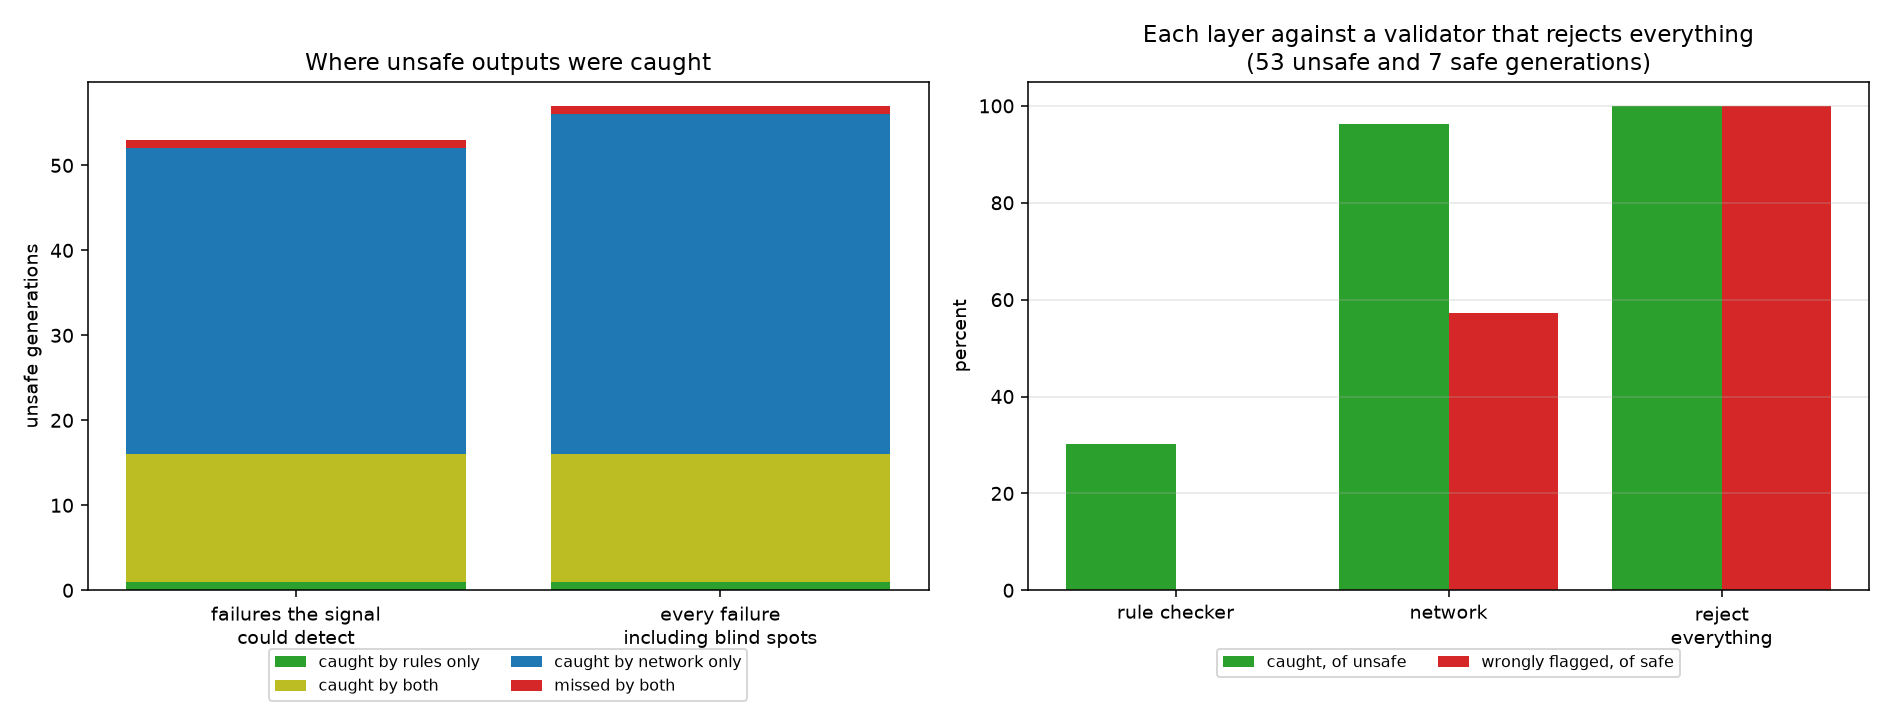

In [9]:
display(Image(os.path.join(FIGS, "study_results.png")))

## 7. What only the network caught, and what got through both

These two lists are the actual output of the project. Everything before this
point exists to produce them.

In [10]:
for scope in ["observable", "strict"]:
    print(f"=== {scope} ===")
    for label in ["stage3_only_examples", "missed_examples"]:
        print(f"  {label}:")
        for item in summary[scope][label][:5]:
            p = item["params"]
            if p:
                print(f"    {item['req_id']:26s} {p['signal']} {p['direction']} "
                      f"{p['threshold']:.1f} delay {p['delay_s']:.1f}s -> {item['failing'][:3]}")
            else:
                print(f"    {item['req_id']:26s} {item['failing'][:3]}")
    print()

=== observable ===
  stage3_only_examples:
    R01_basic_overload         Motor_Current high 51.9 delay 3.0s -> ['cooling_failure:no_trip_damage', 'single_phasing:no_trip_damage']
    R01_basic_overload         Motor_Current high 51.9 delay 3.0s -> ['cooling_failure:no_trip_damage', 'single_phasing:no_trip_damage']
    R01_basic_overload         Motor_Current high 51.9 delay 3.0s -> ['cooling_failure:no_trip_damage', 'single_phasing:no_trip_damage']
    R01_basic_overload         Motor_Current high 51.9 delay 3.0s -> ['cooling_failure:no_trip_damage', 'single_phasing:no_trip_damage']
    R02_two_stage              Motor_Current high 51.9 delay 3.0s -> ['cooling_failure:no_trip_damage', 'single_phasing:no_trip_damage']
  missed_examples:
    R04_winding_temp           Motor_Winding_Temp high 140.0 delay 3.0s -> ['locked_rotor:trip_too_late']

=== strict ===
  stage3_only_examples:
    R01_basic_overload         Motor_Current high 51.9 delay 3.0s -> ['cooling_failure:no_trip_damage', 'si

## 8. Leave one fault out

One arbitrary holdout is not enough to say whether the learned layer
generalises. This holds out each fault family in turn. The margin column is
accuracy minus the majority baseline, and it is the only column worth reading.

In [11]:
sweep = summary.get("leave_one_fault_out")
if not sweep:
    print("run: python src/run_study.py --mock --sweep")
else:
    print(f"{'held out':24s} {'acc':>6s} {'baseline':>9s} {'margin':>8s} {'recall':>8s}")
    for fault, row in sweep.items():
        margin = row["heldout_accuracy"] - row["majority_baseline"]
        print(f"{fault:24s} {row['heldout_accuracy']:6.3f} {row['majority_baseline']:9.3f} "
              f"{margin:+8.3f} {row['recall_unsafe']:8.3f}")

held out                    acc  baseline   margin   recall
locked_rotor              0.521     0.521   +0.000    1.000
progressive_overload      0.571     0.691   -0.120    0.383
sudden_jam                0.758     0.669   +0.090    0.975
single_phasing            0.548     0.822   -0.275    0.453
cooling_failure           0.312     0.688   -0.376    0.000
healthy_start             0.981     0.735   +0.246    0.961
healthy_load_spike        0.938     0.743   +0.195    0.977
